# BTYD from zero to useful: an end-to-end customer value project

BTYD means **Buy Till You Die**.

The name sounds dramatic, but the business question is very practical:

> For customers who can buy whenever they want, who is probably still active, how many purchases should we expect next, and what is that worth?

This notebook is written for a junior analyst, consultant, or product person who has not modeled BTYD before. We will avoid magic. Every idea will be connected to a small business story, visible data, code, and interpretation.

The existing scripts in this folder are the production-style version:

- `01_data_prep.py`: clean transactions and build RFM.
- `02_lifetimes_analysis.py`: fit BG/NBD and Gamma-Gamma with `lifetimes`.
- `03_pymc_analysis.py`: fit Bayesian versions with PyMC-Marketing.
- `04_comparison.py`: compare speed, agreement, ranking, and uncertainty.

Here, we slow down and learn the concepts first.

## 1. When BTYD is the right tool

Use BTYD when all three conditions are true:

| Condition | Meaning | Example |
|---|---|---|
| Customers buy repeatedly | We care about future purchase count, not only one conversion | ecommerce, donations, marketplace orders |
| The relationship is non-contractual | We do not observe a formal cancellation date | a customer simply stops ordering |
| We have transaction history | Purchase dates and amounts are recorded | invoice table, order table, donation table |

BTYD is related to survival analysis, but it is not the same setup.

Survival analysis usually models **time to one event**: churn, death, default, failure.

BTYD models **repeat purchases plus hidden dropout**. A customer may look quiet because they are gone, or because they are alive but not ready to buy today. BTYD tries to separate those two stories.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 20260704
rng = np.random.default_rng(RANDOM_SEED)

## 2. The story: a small online coffee retailer

Imagine a company called **Bean & Byte**. Customers buy coffee beans, filters, mugs, and brewing accessories. There is no cancellation button. If someone stops buying, we only notice silence.

We will generate synthetic transactions so the notebook is self-contained. The hidden truth in the simulation is:

- Some customers are naturally frequent buyers.
- Some customers buy rarely.
- Some customers quietly drop out.
- Order value differs by customer type.

In real life we do not know those hidden traits. We only see transactions.

In [2]:
def simulate_transactions(n_customers=1400):
    obs_start = pd.Timestamp("2024-01-01")
    obs_end = pd.Timestamp("2025-12-31")
    max_signup_offset = 420

    customer_rows = []
    tx_rows = []

    segment_probs = {
        "Everyday brewer": 0.24,
        "Weekend brewer": 0.42,
        "Gift buyer": 0.22,
        "At-risk sampler": 0.12,
    }
    segments = rng.choice(list(segment_probs), size=n_customers, p=list(segment_probs.values()))

    for i, segment in enumerate(segments, start=1):
        customer_id = f"BB{i:05d}"
        signup_date = obs_start + pd.Timedelta(days=int(rng.integers(0, max_signup_offset)))
        available_days = max((obs_end - signup_date).days, 30)

        if segment == "Everyday brewer":
            annual_orders = rng.gamma(shape=9, scale=1.6)
            dropout_hazard = 0.00035
            mean_order_value = rng.lognormal(mean=np.log(42), sigma=0.25)
        elif segment == "Weekend brewer":
            annual_orders = rng.gamma(shape=5, scale=1.25)
            dropout_hazard = 0.00075
            mean_order_value = rng.lognormal(mean=np.log(34), sigma=0.30)
        elif segment == "Gift buyer":
            annual_orders = rng.gamma(shape=2.2, scale=1.0)
            dropout_hazard = 0.00115
            mean_order_value = rng.lognormal(mean=np.log(62), sigma=0.45)
        else:
            annual_orders = rng.gamma(shape=1.6, scale=1.1)
            dropout_hazard = 0.00230
            mean_order_value = rng.lognormal(mean=np.log(24), sigma=0.35)

        daily_rate = max(annual_orders / 365, 0.001)
        dropout_time = rng.exponential(1 / dropout_hazard)
        alive_until = min(available_days, dropout_time)
        active_at_observation_end = dropout_time > available_days

        # Every customer has an initial purchase at signup. BTYD then models repeat buying.
        order_day = 0
        order_number = 1
        while order_day <= alive_until:
            tx_date = signup_date + pd.Timedelta(days=int(round(order_day)))
            if tx_date > obs_end:
                break
            order_value = float(rng.lognormal(mean=np.log(mean_order_value), sigma=0.30))
            tx_rows.append(
                {
                    "customer_id": customer_id,
                    "invoice_date": tx_date,
                    "order_number": order_number,
                    "sales_value": round(order_value, 2),
                    "segment_hidden_for_simulation": segment,
                }
            )
            order_number += 1
            order_day += rng.exponential(1 / daily_rate)

        customer_rows.append(
            {
                "customer_id": customer_id,
                "segment_hidden_for_simulation": segment,
                "signup_date": signup_date,
                "active_at_observation_end_hidden": active_at_observation_end,
                "latent_annual_order_rate": annual_orders,
                "latent_mean_order_value": mean_order_value,
            }
        )

    transactions = pd.DataFrame(tx_rows).sort_values(["customer_id", "invoice_date"]).reset_index(drop=True)
    customers = pd.DataFrame(customer_rows)
    return transactions, customers, obs_end

transactions, customers, observation_end = simulate_transactions()
print("transactions:", transactions.shape)
print("customers:", customers.shape)
print("observation end:", observation_end.date())
transactions.head()

transactions: (12885, 5)
customers: (1400, 6)
observation end: 2025-12-31


,customer_id,invoice_date,order_number,sales_value,segment_hidden_for_simulation
0,BB00001,2024-09-24,1,39.54,Gift buyer
1,BB00002,2024-01-19,1,19.94,Weekend brewer
2,BB00002,2024-02-04,2,29.91,Weekend brewer
3,BB00002,2024-02-24,3,20.12,Weekend brewer
4,BB00002,2024-04-08,4,22.21,Weekend brewer


In [3]:
summary = transactions.groupby("customer_id").agg(
    first_purchase=("invoice_date", "min"),
    last_purchase=("invoice_date", "max"),
    orders=("invoice_date", "count"),
    total_revenue=("sales_value", "sum"),
    avg_order_value=("sales_value", "mean"),
).reset_index()
summary["customer_age_days"] = (observation_end - summary["first_purchase"]).dt.days
summary["days_since_last_order"] = (observation_end - summary["last_purchase"]).dt.days

summary.describe().round(2)

,first_purchase,last_purchase,orders,total_revenue,avg_order_value,customer_age_days,days_since_last_order
count,1400,1400,1400.00,1400.00,1400.00,1400.00,1400.00
mean,2024-07-29 08:39:25.714285824,2025-06-18 02:25:01.714285824,9.20,399.18,45.12,519.64,195.90
min,2024-01-01 00:00:00,2024-01-01 00:00:00,1.00,7.96,7.96,311.00,0.00
25%,2024-04-12 00:00:00,2025-01-23 00:00:00,3.00,105.15,29.50,413.00,27.00
50%,2024-07-27 00:00:00,2025-09-18 00:00:00,6.00,255.34,39.71,522.00,104.00
75%,2024-11-13 00:00:00,2025-12-04 00:00:00,13.00,555.55,52.56,628.00,342.00
max,2025-02-23 00:00:00,2025-12-31 00:00:00,60.00,3497.86,255.52,730.00,730.00
std,NaN,NaN,8.76,421.17,25.38,122.24,202.54


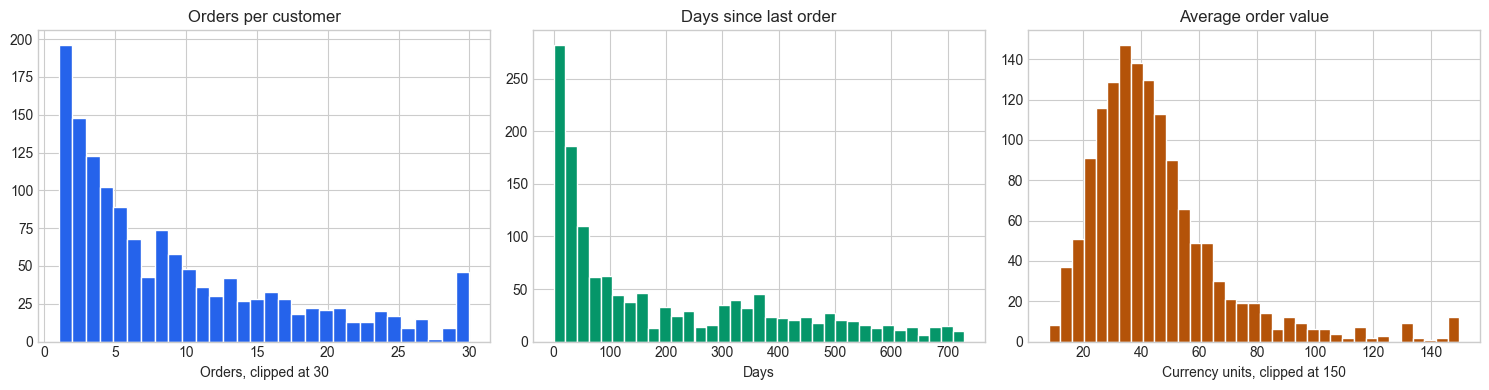

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(summary["orders"].clip(upper=30), bins=30, color="#2563EB", edgecolor="white")
axes[0].set_title("Orders per customer")
axes[0].set_xlabel("Orders, clipped at 30")

axes[1].hist(summary["days_since_last_order"], bins=35, color="#059669", edgecolor="white")
axes[1].set_title("Days since last order")
axes[1].set_xlabel("Days")

axes[2].hist(summary["avg_order_value"].clip(upper=150), bins=35, color="#B45309", edgecolor="white")
axes[2].set_title("Average order value")
axes[2].set_xlabel("Currency units, clipped at 150")

plt.tight_layout()
plt.show()

## 3. The four BTYD columns: frequency, recency, T, monetary value

BTYD does not use a raw transaction table directly. It compresses each customer's history into a small set of sufficient statistics.

| Column | Plain-English meaning | Common beginner mistake |
|---|---|---|
| `frequency` | repeat purchases after the first purchase | thinking it means total purchases |
| `recency` | time between first and most recent purchase | thinking it means days since last purchase |
| `T` | customer age at the end of observation | using a different end date per customer |
| `monetary_value` | average value of repeat purchases | including one-time buyers in Gamma-Gamma |

The names are slightly annoying. Especially `recency`: in lifetimes, high recency means the customer kept buying over a long span. It is not the same as "how recently they bought." We can calculate both, but the model expects the lifetimes definition.

In [5]:
rfm = summary_data_from_transaction_data(
    transactions,
    customer_id_col="customer_id",
    datetime_col="invoice_date",
    monetary_value_col="sales_value",
    observation_period_end=observation_end,
    freq="D",
)

rfm = rfm.reset_index()
rfm.head(10)

,customer_id,frequency,recency,T,monetary_value
0,BB00001,0.0,0.0,463.0,0.000000
1,BB00002,14.0,376.0,712.0,28.207143
2,BB00003,15.0,589.0,636.0,56.152667
3,BB00004,28.0,637.0,646.0,66.858571
4,BB00005,11.0,427.0,527.0,36.237273
5,BB00006,5.0,288.0,327.0,69.566000
6,BB00007,8.0,360.0,414.0,30.466250
7,BB00008,0.0,0.0,373.0,0.000000
8,BB00009,9.0,476.0,574.0,56.704444
9,BB00010,0.0,0.0,553.0,0.000000


In [6]:
print("Rows:", len(rfm))
print("One-time buyers:", int((rfm["frequency"] == 0).sum()))
print("Repeat buyers:", int((rfm["frequency"] > 0).sum()))
print("Repeat-buyer share:", round((rfm["frequency"] > 0).mean(), 3))
rfm[["frequency", "recency", "T", "monetary_value"]].describe().round(2)

Rows: 1400
One-time buyers: 198
Repeat buyers: 1202
Repeat-buyer share: 0.859


,frequency,recency,T,monetary_value
count,1400.00,1400.00,1400.00,1400.00
mean,8.06,323.74,519.64,38.37
std,8.56,212.93,122.24,25.96
min,0.00,0.00,311.00,0.00
25%,2.00,128.50,413.00,24.74
50%,5.00,344.50,522.00,36.92
75%,12.00,500.00,628.00,50.08
max,57.00,729.00,730.00,190.72


In [7]:
example_customer = rfm.sort_values(["frequency", "T"], ascending=[False, False]).iloc[0]["customer_id"]
example_timeline = transactions[transactions["customer_id"] == example_customer].copy()
example_rfm = rfm[rfm["customer_id"] == example_customer]

print("Example customer:", example_customer)
display(example_rfm)
display(example_timeline.head(12))

Example customer: BB00503


,customer_id,frequency,recency,T,monetary_value
502,BB00503,57.0,684.0,686.0,42.559123


,customer_id,invoice_date,order_number,sales_value,segment_hidden_for_simulation
4828,BB00503,2024-02-14,1,47.82,Everyday brewer
4829,BB00503,2024-02-14,2,39.40,Everyday brewer
4830,BB00503,2024-02-28,3,29.22,Everyday brewer
4831,BB00503,2024-03-06,4,28.72,Everyday brewer
4832,BB00503,2024-03-13,5,28.54,Everyday brewer
4833,BB00503,2024-03-17,6,38.63,Everyday brewer
4834,BB00503,2024-04-15,7,49.78,Everyday brewer
4835,BB00503,2024-06-13,8,42.49,Everyday brewer
4836,BB00503,2024-06-20,9,52.61,Everyday brewer
4837,BB00503,2024-07-01,10,59.33,Everyday brewer


## 4. Fit BG/NBD: buying frequency plus hidden dropout

The BG/NBD model is the workhorse transaction model.

It assumes each customer has:

- A personal purchase rate: some people buy frequently, others rarely.
- A hidden dropout process: after each purchase, the customer may become inactive without telling us.

The model outputs two business-friendly quantities:

- `expected_purchases_180d`: how many purchases we expect in the next 180 days.
- `p_alive`: probability the customer is still active, given their purchase pattern so far.

`p_alive` is not morality, loyalty, or satisfaction. It is a model-based probability that the customer's purchase process has not stopped.

In [8]:
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(rfm["frequency"], rfm["recency"], rfm["T"])

print("BG/NBD parameters")
display(bgf.summary.round(4))

rfm["expected_purchases_180d"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    180,
    rfm["frequency"],
    rfm["recency"],
    rfm["T"],
)
rfm["p_alive"] = bgf.conditional_probability_alive(
    rfm["frequency"],
    rfm["recency"],
    rfm["T"],
)

rfm[["expected_purchases_180d", "p_alive"]].describe().round(3)

BG/NBD parameters


,coef,se(coef),lower 95% bound,upper 95% bound
r,0.9214,0.0403,0.8425,1.0003
alpha,49.9884,2.6720,44.7512,55.2255
a,0.0758,0.0088,0.0585,0.0931
b,0.8717,0.1090,0.6581,1.0854


,expected_purchases_180d,p_alive
count,1202.000,1400.000
mean,2.896,0.833
std,2.652,0.272
min,0.000,0.000
25%,0.768,0.817
50%,2.172,0.974
75%,4.346,0.993
max,18.125,1.000


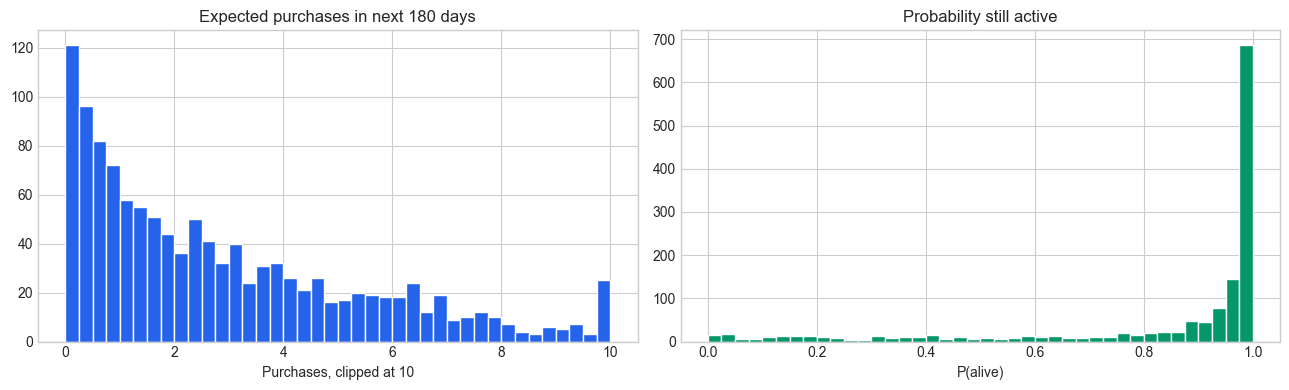

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(rfm["expected_purchases_180d"].clip(upper=10), bins=40, color="#2563EB", edgecolor="white")
axes[0].set_title("Expected purchases in next 180 days")
axes[0].set_xlabel("Purchases, clipped at 10")

axes[1].hist(rfm["p_alive"], bins=40, color="#059669", edgecolor="white")
axes[1].set_title("Probability still active")
axes[1].set_xlabel("P(alive)")

plt.tight_layout()
plt.show()

In [10]:
inspect_cols = ["customer_id", "frequency", "recency", "T", "monetary_value", "expected_purchases_180d", "p_alive"]
rfm.sort_values("expected_purchases_180d", ascending=False)[inspect_cols].head(10).round(3)

,customer_id,frequency,recency,T,monetary_value,expected_purchases_180d,p_alive
1288,BB01289,44.0,387.0,389.0,56.875,18.125,0.998
338,BB00339,31.0,339.0,350.0,32.834,14.063,0.994
502,BB00503,57.0,684.0,686.0,42.559,14.021,0.998
1022,BB01023,51.0,697.0,702.0,67.502,12.296,0.998
356,BB00357,44.0,544.0,588.0,40.043,12.033,0.959
561,BB00562,24.0,311.0,317.0,36.272,11.964,0.995
368,BB00369,32.0,440.0,445.0,38.335,11.782,0.997
1239,BB01240,23.0,325.0,330.0,29.403,11.099,0.995
1326,BB01327,39.0,583.0,592.0,68.295,11.044,0.997
789,BB00790,37.0,534.0,560.0,33.835,10.956,0.989


## 5. Validate with a calibration and holdout split

A professional BTYD workflow should ask:

> If we train on the earlier part of history, can we predict purchases in the later part?

This is not perfect validation, but it is much better than fitting once and admiring the output.

In [11]:
calibration_end = observation_end - pd.Timedelta(days=180)

cal_holdout = calibration_and_holdout_data(
    transactions,
    customer_id_col="customer_id",
    datetime_col="invoice_date",
    calibration_period_end=calibration_end,
    observation_period_end=observation_end,
    freq="D",
)

bgf_cal = BetaGeoFitter(penalizer_coef=0.01)
bgf_cal.fit(cal_holdout["frequency_cal"], cal_holdout["recency_cal"], cal_holdout["T_cal"])

holdout_days = (observation_end - calibration_end).days
cal_holdout["predicted_holdout_purchases"] = bgf_cal.conditional_expected_number_of_purchases_up_to_time(
    holdout_days,
    cal_holdout["frequency_cal"],
    cal_holdout["recency_cal"],
    cal_holdout["T_cal"],
)

eval_df = cal_holdout.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["frequency_holdout", "predicted_holdout_purchases"]
).copy()

actual = eval_df["frequency_holdout"]
pred = eval_df["predicted_holdout_purchases"]
mae = mean_absolute_error(actual, pred)
rmse = mean_squared_error(actual, pred) ** 0.5
rank_corr = spearmanr(actual, pred).statistic

print(f"Holdout window: {holdout_days} days")
print(f"Evaluated customers: {len(eval_df):,} of {len(cal_holdout):,}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Spearman rank correlation: {rank_corr:.3f}")
eval_df[["frequency_cal", "recency_cal", "T_cal", "frequency_holdout", "predicted_holdout_purchases"]].head()

Holdout window: 180 days
Evaluated customers: 1,212 of 1,400
MAE: 1.664
RMSE: 2.277
Spearman rank correlation: 0.743


,frequency_cal,recency_cal,T_cal,frequency_holdout,predicted_holdout_purchases
customer_id,,,,,
BB00002,14.0,376.0,532.0,0.0,3.542125
BB00003,13.0,438.0,456.0,2.0,4.871628
BB00004,23.0,466.0,466.0,5.0,8.222735
BB00005,8.0,255.0,347.0,3.0,3.793440
BB00006,2.0,91.0,147.0,3.0,2.460970


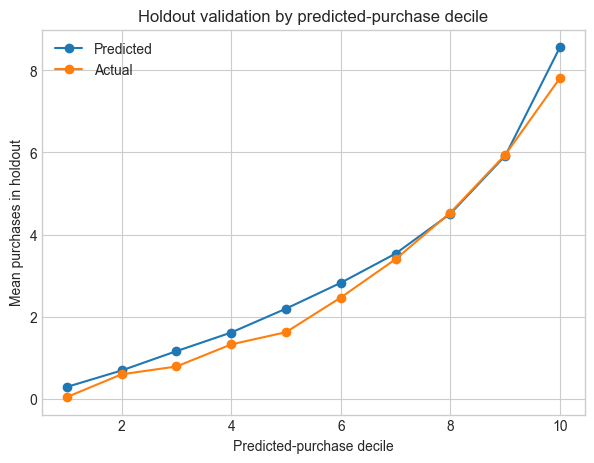

,customers,predicted_purchases,actual_purchases
0,122,0.296,0.049
1,121,0.697,0.603
2,121,1.166,0.793
3,121,1.620,1.331
4,121,2.201,1.628
5,121,2.829,2.471
6,121,3.540,3.405
7,121,4.510,4.537
8,121,5.917,5.942
9,122,8.563,7.811


In [12]:
plot_df = eval_df.copy()
plot_df["pred_bin"] = pd.qcut(plot_df["predicted_holdout_purchases"], q=10, duplicates="drop")
calibration_table = plot_df.groupby("pred_bin", observed=True).agg(
    customers=("frequency_holdout", "size"),
    predicted_purchases=("predicted_holdout_purchases", "mean"),
    actual_purchases=("frequency_holdout", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(calibration_table.index + 1, calibration_table["predicted_purchases"], marker="o", label="Predicted")
ax.plot(calibration_table.index + 1, calibration_table["actual_purchases"], marker="o", label="Actual")
ax.set_title("Holdout validation by predicted-purchase decile")
ax.set_xlabel("Predicted-purchase decile")
ax.set_ylabel("Mean purchases in holdout")
ax.legend()
plt.show()

calibration_table[["customers", "predicted_purchases", "actual_purchases"]].round(3)

## 6. Fit Gamma-Gamma: expected money per purchase

BG/NBD predicts **how many** purchases. Gamma-Gamma predicts **how much money per purchase**.

Gamma-Gamma uses only customers with repeat purchases, because one-time buyers have no repeat-purchase monetary average.

Important assumption:

> Purchase frequency and average order value should not be strongly correlated.

If the correlation is high, the model is forcing apart two behaviors that are actually linked. That does not automatically kill the project, but it should make you cautious.

In [13]:
repeat_customers = rfm[(rfm["frequency"] > 0) & (rfm["monetary_value"] > 0)].copy()
frequency_monetary_corr = repeat_customers[["frequency", "monetary_value"]].corr().iloc[0, 1]
print(f"Correlation between frequency and monetary_value: {frequency_monetary_corr:.3f}")

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(repeat_customers["frequency"], repeat_customers["monetary_value"])

display(ggf.summary.round(4))

repeat_customers["expected_avg_order_value"] = ggf.conditional_expected_average_profit(
    repeat_customers["frequency"],
    repeat_customers["monetary_value"],
)
repeat_customers[["monetary_value", "expected_avg_order_value"]].describe().round(2)

Correlation between frequency and monetary_value: -0.042


,coef,se(coef),lower 95% bound,upper 95% bound
p,4.3807,0.1430,4.1004,4.661
q,0.8781,0.0311,0.8172,0.939
v,4.2610,0.1429,3.9810,4.541


,monetary_value,expected_avg_order_value
count,1202.00,1202.00
mean,44.70,46.28
std,22.41,22.92
min,9.36,10.50
25%,30.57,31.99
50%,40.04,41.21
75%,53.07,54.20
max,190.72,200.56


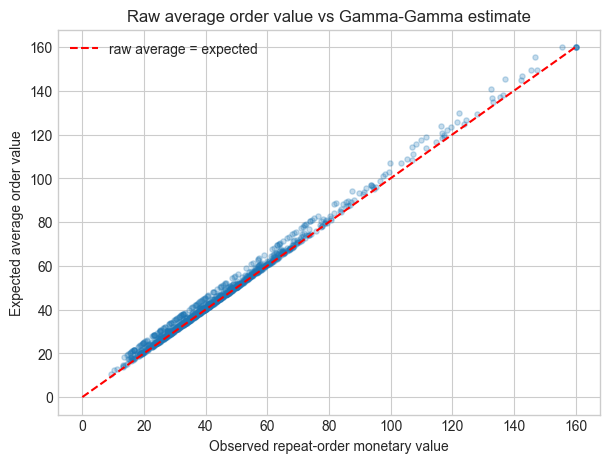

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    repeat_customers["monetary_value"].clip(upper=160),
    repeat_customers["expected_avg_order_value"].clip(upper=160),
    alpha=0.25,
    s=14,
)
ax.plot([0, 160], [0, 160], color="red", linestyle="--", label="raw average = expected")
ax.set_title("Raw average order value vs Gamma-Gamma estimate")
ax.set_xlabel("Observed repeat-order monetary value")
ax.set_ylabel("Expected average order value")
ax.legend()
plt.show()

## 7. Estimate customer lifetime value

A simple BTYD CLV idea is:

> expected future purchases x expected value per purchase, adjusted for discounting

The `lifetimes` implementation handles the math for us. We will estimate 6-month CLV using:

- BG/NBD for future purchase count.
- Gamma-Gamma for value per purchase.
- A small monthly discount rate.

This is expected value, not guaranteed revenue.

In [15]:
repeat_customers["clv_6m"] = ggf.customer_lifetime_value(
    transaction_prediction_model=bgf,
    frequency=repeat_customers["frequency"],
    recency=repeat_customers["recency"],
    T=repeat_customers["T"],
    monetary_value=repeat_customers["monetary_value"],
    time=6,
    freq="D",
    discount_rate=0.01,
)

repeat_customers["expected_purchases_180d"] = rfm.set_index("customer_id").loc[
    repeat_customers["customer_id"], "expected_purchases_180d"
].values
repeat_customers["p_alive"] = rfm.set_index("customer_id").loc[
    repeat_customers["customer_id"], "p_alive"
].values

repeat_customers[["expected_purchases_180d", "expected_avg_order_value", "p_alive", "clv_6m"]].describe().round(2)

,expected_purchases_180d,expected_avg_order_value,p_alive,clv_6m
count,1202.00,1202.00,1202.00,1202.00
mean,2.90,46.28,0.81,124.43
std,2.65,22.92,0.28,126.12
min,0.00,10.50,0.00,0.00
25%,0.77,31.99,0.75,30.43
50%,2.17,41.21,0.96,80.86
75%,4.35,54.20,0.99,175.96
max,18.12,200.56,1.00,998.16


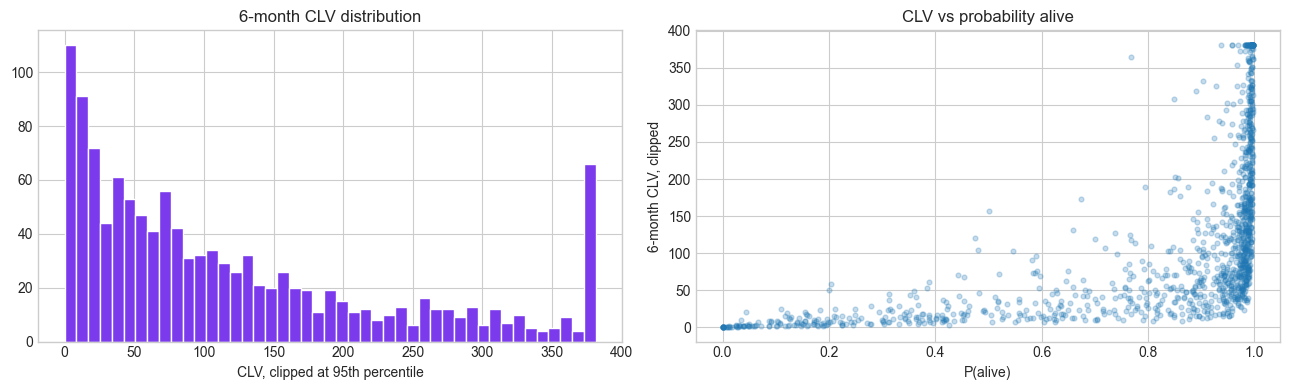

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(repeat_customers["clv_6m"].clip(upper=repeat_customers["clv_6m"].quantile(0.95)), bins=45, color="#7C3AED", edgecolor="white")
axes[0].set_title("6-month CLV distribution")
axes[0].set_xlabel("CLV, clipped at 95th percentile")

axes[1].scatter(repeat_customers["p_alive"], repeat_customers["clv_6m"].clip(upper=repeat_customers["clv_6m"].quantile(0.95)), alpha=0.25, s=12)
axes[1].set_title("CLV vs probability alive")
axes[1].set_xlabel("P(alive)")
axes[1].set_ylabel("6-month CLV, clipped")

plt.tight_layout()
plt.show()

In [17]:
repeat_customers.sort_values("clv_6m", ascending=False)[
    ["customer_id", "frequency", "recency", "T", "monetary_value", "expected_purchases_180d", "p_alive", "expected_avg_order_value", "clv_6m"]
].head(12).round(2)

,customer_id,frequency,recency,T,monetary_value,expected_purchases_180d,p_alive,expected_avg_order_value,clv_6m
1288,BB01289,44.0,387.0,389.0,56.88,18.12,1.00,57.01,998.16
1022,BB01023,51.0,697.0,702.0,67.50,12.30,1.00,67.62,803.24
1326,BB01327,39.0,583.0,592.0,68.30,11.04,1.00,68.45,730.32
911,BB00912,26.0,382.0,386.0,65.41,10.92,1.00,65.65,692.29
439,BB00440,26.0,603.0,664.0,94.78,6.51,0.97,95.04,598.08
743,BB00744,25.0,535.0,539.0,77.55,7.81,1.00,77.81,586.86
502,BB00503,57.0,684.0,686.0,42.56,14.02,1.00,42.65,577.72
1385,BB01386,39.0,608.0,610.0,54.16,10.76,1.00,54.31,564.44
1198,BB01199,26.0,508.0,508.0,66.93,8.56,1.00,67.16,555.41
43,BB00044,34.0,568.0,580.0,57.91,9.83,1.00,58.08,551.77


## 8. Turn model output into an action table

A BTYD model becomes useful when it changes decisions.

For example:

- High CLV and high P(alive): protect and reward.
- High CLV and low P(alive): win-back priority.
- Low CLV and high P(alive): automate and keep costs low.
- Low CLV and low P(alive): do not overspend.

This is also where you should bring in margin, campaign cost, and capacity. A model can rank customers, but the business still chooses the action threshold.

In [18]:
scorecard = repeat_customers.copy()
scorecard["clv_percentile"] = scorecard["clv_6m"].rank(pct=True)
scorecard["p_alive_percentile"] = scorecard["p_alive"].rank(pct=True)

conditions = [
    (scorecard["clv_percentile"] >= 0.80) & (scorecard["p_alive"] >= 0.75),
    (scorecard["clv_percentile"] >= 0.80) & (scorecard["p_alive"] < 0.75),
    (scorecard["clv_percentile"] < 0.80) & (scorecard["p_alive"] >= 0.75),
]
choices = [
    "Protect: high value and active",
    "Win back: valuable but fading",
    "Nurture cheaply: active but lower value",
]
scorecard["recommended_action"] = np.select(conditions, choices, default="Low-touch: low value or inactive")

action_summary = scorecard.groupby("recommended_action").agg(
    customers=("customer_id", "count"),
    avg_clv_6m=("clv_6m", "mean"),
    avg_p_alive=("p_alive", "mean"),
    avg_expected_purchases_180d=("expected_purchases_180d", "mean"),
).sort_values("avg_clv_6m", ascending=False)

action_summary.round(2)

,customers,avg_clv_6m,avg_p_alive,avg_expected_purchases_180d
recommended_action,,,,
Protect: high value and active,241,333.72,0.99,6.88
Nurture cheaply: active but lower value,661,94.72,0.94,2.53
Low-touch: low value or inactive,300,21.76,0.36,0.50


In [19]:
scorecard.sort_values("clv_6m", ascending=False)[
    ["customer_id", "frequency", "recency", "T", "p_alive", "expected_purchases_180d", "expected_avg_order_value", "clv_6m", "recommended_action"]
].head(20).round(2)

,customer_id,frequency,recency,T,p_alive,expected_purchases_180d,expected_avg_order_value,clv_6m,recommended_action
1288,BB01289,44.0,387.0,389.0,1.00,18.12,57.01,998.16,Protect: high value and active
1022,BB01023,51.0,697.0,702.0,1.00,12.30,67.62,803.24,Protect: high value and active
1326,BB01327,39.0,583.0,592.0,1.00,11.04,68.45,730.32,Protect: high value and active
911,BB00912,26.0,382.0,386.0,1.00,10.92,65.65,692.29,Protect: high value and active
439,BB00440,26.0,603.0,664.0,0.97,6.51,95.04,598.08,Protect: high value and active
743,BB00744,25.0,535.0,539.0,1.00,7.81,77.81,586.86,Protect: high value and active
502,BB00503,57.0,684.0,686.0,1.00,14.02,42.65,577.72,Protect: high value and active
1385,BB01386,39.0,608.0,610.0,1.00,10.76,54.31,564.44,Protect: high value and active
1198,BB01199,26.0,508.0,508.0,1.00,8.56,67.16,555.41,Protect: high value and active
43,BB00044,34.0,568.0,580.0,1.00,9.83,58.08,551.77,Protect: high value and active


## 9. What about PyMC-Marketing?

This notebook used `lifetimes` because it is fast and perfect for learning the mechanics.

The existing folder also contains a PyMC-Marketing implementation. Conceptually, the difference is:

| Tool | What you get | Tradeoff |
|---|---|---|
| `lifetimes` | Fast point estimates | No full posterior uncertainty |
| `pymc-marketing` | Bayesian uncertainty for parameters and customer predictions | Slower and requires more statistical care |

For a first business baseline, use `lifetimes`.

For high-stakes budget allocation, executive forecasting, or cases where uncertainty matters, use PyMC-Marketing after the baseline works.

## 10. Common BTYD mistakes to avoid

1. **Using BTYD for contractual churn.** If customers explicitly cancel, survival models or churn models may be a better first choice.

2. **Confusing `recency` with days since last order.** In `lifetimes`, recency is time from first purchase to most recent purchase.

3. **Treating one-time buyers as useless.** BG/NBD can score them, but Gamma-Gamma needs repeat buyers for monetary modeling.

4. **Ignoring returns, refunds, and outliers.** Garbage transaction cleaning gives garbage CLV.

5. **Thinking CLV is cash in the bank.** CLV is an expected value. Campaign costs, margins, uncertainty, and operational constraints still matter.

6. **Forgetting validation.** Always backtest on a holdout window before trusting rankings.

7. **Using future information.** If a feature is not known at the scoring date, it does not belong in the model.

## Final consultant summary

A professional BTYD recommendation sounds like this:

> We modeled non-contractual repeat purchases using BG/NBD for transaction frequency and Gamma-Gamma for order value. The model estimates both probability of being active and expected 6-month value. Holdout validation shows whether the purchase ranking is useful. We recommend using the scorecard to separate high-value active customers from high-value fading customers, with different retention actions for each group.

That is the core idea: not just predicting revenue, but deciding where attention is worth spending.